# Titanic Survival Analysis[¶](#Titanic-Survival-Analysis)

**Objective:** Explore the Titanic dataset to understand what factors influenced passenger survival.

**Dataset:** [Titanic Dataset (Kaggle)](https://www.kaggle.com/c/titanic/data)

This notebook covers: Data Loading & Inspection, Missing Value Analysis, Univariate Analysis, Bivariate Analysis (Survival Relationships), Correlation Analysis, and Feature Engineering.

## 1. Imports and Setup
First, we import the necessary libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

## 2. Data Loading & Inspection
Here we load the dataset and perform an initial inspection to understand its structure, data types, and checking for any missing values.

In [2]:
df = pd.read_csv('data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print('--- SHAPE ---')
print(df.shape)

print('\n--- INFO ---')
df.info()

print('\n--- MISSING VALUES ---')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).sort_values('missing', ascending=False)

--- SHAPE ---
(891, 12)

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

--- MISSING VALUES ---


,missing,pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2
PassengerId,0,0.0
Name,0,0.0
Pclass,0,0.0
Survived,0,0.0
Sex,0,0.0
Parch,0,0.0
SibSp,0,0.0


### Step 3: Structure & Missing Values

We have **891 rows and 12 columns**. Before touching anything else, the first job is always to know where the gaps are.

<details>
<summary>📝 Note: What the missing values tell us</summary>

- **Cabin** is missing in the vast majority of rows (~77%). This isn't really a "fill it in" problem — it's a "decide if this column is usable at all" problem. Interestingly, the *fact* that Cabin is missing is itself informative: it strongly correlates with lower-class, lower-fare passengers whose cabins were never documented.
- **Age** is missing in about 20% of rows — significant, but recoverable with thoughtful imputation (e.g. median age grouped by title or class, rather than a single blind average).
- **Embarked** is missing in just 2 rows — trivial, we'll just fill these with the most common port.

The core EDA principle here: missingness isn't just noise to clean up. Sometimes *why* something is missing carries real signal about the data-generating process.

</details>

In [4]:
counts = df['Survived'].value_counts()
pct = df['Survived'].value_counts(normalize=True).round(3) * 100
pd.DataFrame({'count': counts, 'pct': pct})

,count,pct
Survived,,
0,549,61.6
1,342,38.4


### Step 4: Target Variable Distribution

<details>
<summary>📝 Note: Why this matters before modeling</summary>

Survival is **imbalanced** — roughly 62% died vs 38% survived. This isn't extreme imbalance (like fraud detection at 1%), but it's enough that "accuracy" alone would be a misleading metric later. A dummy model that just predicts "everyone dies" would score ~62% accuracy without learning anything. Keep this in mind if you eventually build a classifier — metrics like precision, recall, and F1-score (or a confusion matrix) will tell a more honest story.

</details>

In [5]:
df[['Age','Fare','SibSp','Parch']].describe()

,Age,Fare,SibSp,Parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


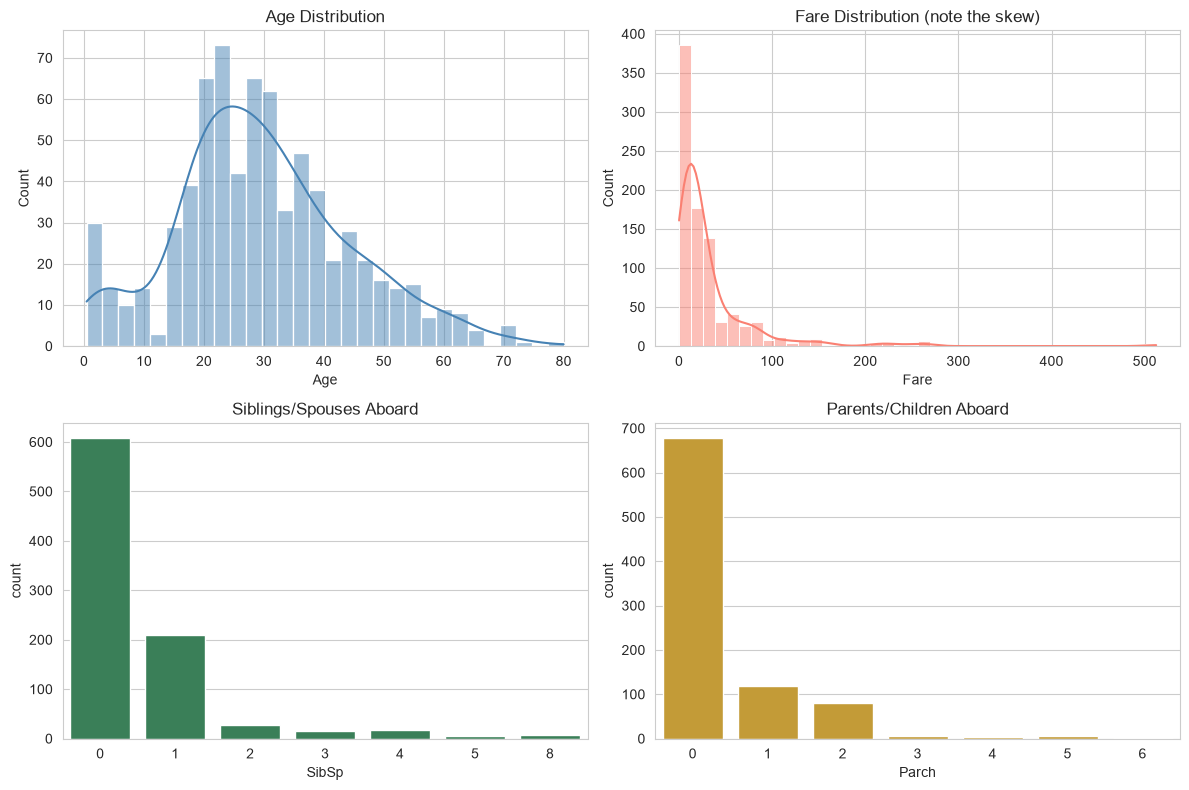

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['Age'].dropna(), bins=30, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Age Distribution')

sns.histplot(df['Fare'], bins=40, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Fare Distribution (note the skew)')

sns.countplot(x='SibSp', data=df, ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Siblings/Spouses Aboard')

sns.countplot(x='Parch', data=df, ax=axes[1,1], color='goldenrod')
axes[1,1].set_title('Parents/Children Aboard')

plt.tight_layout()
plt.show()

### Step 5: Univariate Analysis — Numeric Features

<details>
<summary>📝 Note: What the shapes are telling us</summary>

- **Age**: roughly bell-shaped, slightly right-skewed, with a small bump near 0 (infants). Mostly concentrated in the 20s-30s.
- **Fare**: heavily right-skewed. Most tickets are cheap, but a handful of very expensive fares pull the mean well above the median. This is a strong candidate for a log-transform later if we build a model.
- **SibSp / Parch**: both dominated by 0 — most passengers traveled alone or with just one family member. Long-tail distributions with a few large families.

</details>

In [7]:
for col in ['Sex','Pclass','Embarked']:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False))
    print()

--- Sex ---
Sex
male      577
female    314
Name: count, dtype: int64

--- Pclass ---
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

--- Embarked ---
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64



In [8]:
print('--- Survival rate by Sex ---')
print(df.groupby('Sex')['Survived'].mean().round(3))

print('\n--- Survival rate by Pclass ---')
print(df.groupby('Pclass')['Survived'].mean().round(3))

print('\n--- Survival rate by Sex x Pclass ---')
print(df.groupby(['Pclass','Sex'])['Survived'].mean().round(3))

--- Survival rate by Sex ---
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

--- Survival rate by Pclass ---
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64

--- Survival rate by Sex x Pclass ---
Pclass  Sex   
1       female    0.968
        male      0.369
2       female    0.921
        male      0.157
3       female    0.500
        male      0.135
Name: Survived, dtype: float64


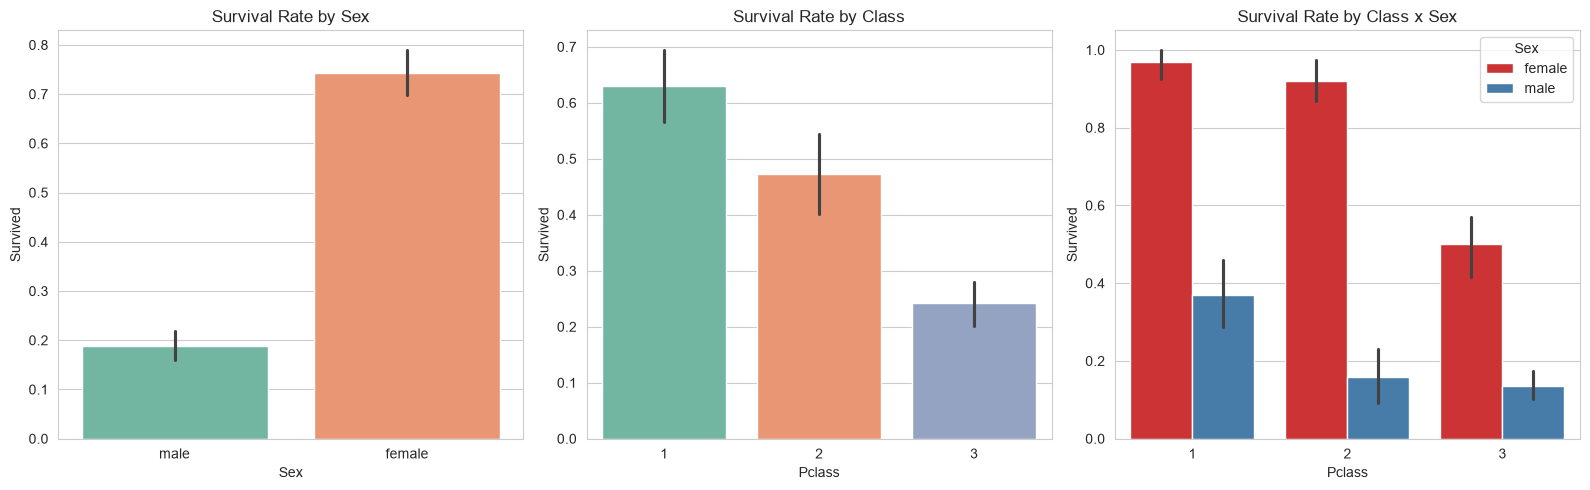

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(x='Sex', y='Survived', data=df, hue='Sex', legend=False, palette='Set2', ax=axes[0])
axes[0].set_title('Survival Rate by Sex')

sns.barplot(x='Pclass', y='Survived', data=df, hue='Pclass', legend=False, palette='Set2', ax=axes[1])
axes[1].set_title('Survival Rate by Class')

sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, palette='Set1', ax=axes[2])
axes[2].set_title('Survival Rate by Class x Sex')

plt.tight_layout()
plt.show()

### Step 6: Survival by Sex and Class — "Women and Children First" in the Data

<details>
<summary>📝 Note: The strongest signal in the whole dataset</summary>

This is the core story of the Titanic disaster showing up numerically:

- **Sex is the single strongest predictor of survival.** Women survived at ~74%, men at only ~19%. That's the "women and children first" evacuation protocol showing up directly in the data.
- **Class mattered enormously too.** 1st class survival (~63%) is more than double 3rd class (~24%) — money and social status bought a better shot at a lifeboat.
- **Combined, it's stark**: a 1st-class woman had close to a 97% survival rate, while a 3rd-class man had roughly 13.5%. Two very different disasters happened to two different groups of people on the same ship.

</details>

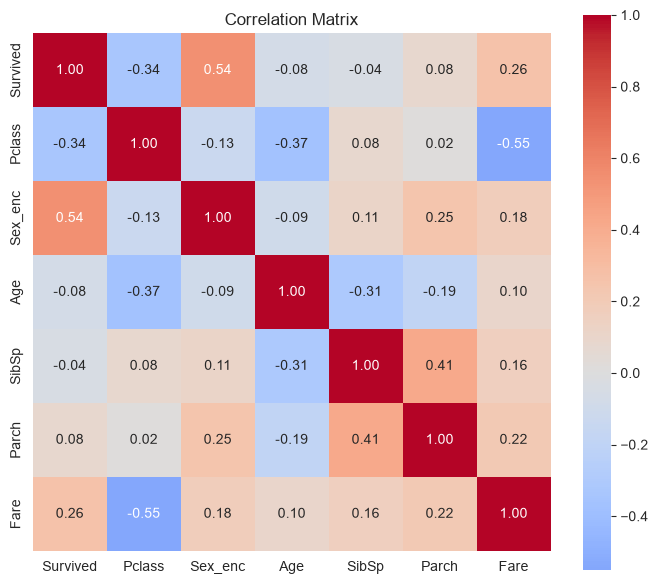

In [10]:
df_enc = df.copy()
df_enc['Sex_enc'] = df_enc['Sex'].map({'male':0,'female':1})

numeric_cols = ['Survived','Pclass','Sex_enc','Age','SibSp','Parch','Fare']
corr = df_enc[numeric_cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [11]:
# Extract title from Name (Mr, Mrs, Miss, Master, rare titles, etc.)
df['Title'] = df['Name'].str.extract(r',\s*([^.]*)\.')
print('--- Survival rate by Title ---')
print(df.groupby('Title')['Survived'].mean().round(2).sort_values(ascending=False))

# Family size = siblings/spouses + parents/children + self
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
print('\n--- Survival rate by FamilySize ---')
print(df.groupby('FamilySize')['Survived'].mean().round(2))

# Whether Cabin was recorded at all (proxy for wealth/documentation)
df['HasCabin'] = df['Cabin'].notnull().astype(int)
print('\n--- Survival rate by HasCabin ---')
print(df.groupby('HasCabin')['Survived'].mean().round(2))

--- Survival rate by Title ---
Title
Lady            1.00
Ms              1.00
Sir             1.00
Mme             1.00
the Countess    1.00
Mlle            1.00
Mrs             0.79
Miss            0.70
Master          0.57
Major           0.50
Col             0.50
Dr              0.43
Mr              0.16
Capt            0.00
Jonkheer        0.00
Don             0.00
Rev             0.00
Name: Survived, dtype: float64

--- Survival rate by FamilySize ---
FamilySize
1     0.30
2     0.55
3     0.58
4     0.72
5     0.20
6     0.14
7     0.33
8     0.00
11    0.00
Name: Survived, dtype: float64

--- Survival rate by HasCabin ---
HasCabin
0    0.30
1    0.67
Name: Survived, dtype: float64


### Step 7: Correlation & Feature Engineering

<details>
<summary>📝 Note: Why engineered features beat raw ones</summary>

- **Correlation matrix** confirms `Sex_enc` (0.54) as the strongest single correlate of survival, and shows `Pclass` and `Fare` are heavily correlated with each other (-0.55) — expected, since fare is basically a proxy for class. Worth remembering if we ever build a model: using both raw could introduce multicollinearity.
- **Title** (extracted from Name) captures social status *and* age/sex in one feature — "Master" (young boys) survives far better than adult "Mr", echoing "children first."
- **FamilySize** reveals a sweet spot: small families (2-4) survived best, while solo travelers and very large families (5+) did worse — likely harder to coordinate evacuation as a large group, and no one to help you as a lone traveler.
- **HasCabin** turns out to be a sneaky-useful feature: it's not really about *having* a cabin, it's a proxy for wealth — poorer passengers' cabins were simply never recorded. A great reminder that *missingness itself* can carry signal.

</details>

## Summary & Key Findings

1. **Survival was driven by social factors, not chance.** "Women and children first" plus class privilege explain most of the variance in who survived.
2. **Sex is the single strongest predictor** — women survived at ~74%, men at ~19%.
3. **Class and Fare are strongly linked** (both proxies for wealth) — 1st class survived at ~63%, 3rd class at ~24%.
4. **Engineered features outperform raw ones**: `Title`, `FamilySize`, and `HasCabin` all carry more predictive signal than the columns they were derived from.
5. **Missing data needs a deliberate strategy**: `Cabin`'s missingness is itself informative (don't just drop it blindly), `Age` should be imputed thoughtfully (e.g. median by Title/Pclass group), and `Embarked`'s 2 missing values can just be filled with the mode.

**Next steps:** data cleaning + preprocessing pipeline, baseline model (logistic regression), then iterate with more complex models (Random Forest, Gradient Boosting).

## Data Cleaning & Preprocessing

Goal: transform the raw dataframe into a fully numeric, complete (no missing values) dataset ready for model training.

In [12]:
# Age: impute with median grouped by Title (more accurate than a single global median)
df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

# In case any Title group had zero known ages, fall back to overall median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Embarked: only 2 missing, fill with the mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Confirm no missing values remain except Cabin (which we're dropping anyway)
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Title            0
FamilySize       0
HasCabin         0
dtype: int64

### Step 1: Handling Missing Values

<details>
<summary>📝 Note: Why group-based imputation beats a single median</summary>

Filling `Age` with one global median ignores that a "Master" (young boy) and a "Mr" (adult man) have very different typical ages. Imputing by `Title` group gives a much more realistic estimate — a missing "Master" age gets filled with the median age of other Masters, not the median age of the entire ship. `Embarked` only had 2 missing values, so filling with the mode (most common port) is safe and won't meaningfully bias anything.

</details>

In [13]:
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'
}
df['Title'] = df['Title'].map(lambda t: title_map.get(t, 'Rare'))
df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

### Step 2: Bucketing Rare Titles

<details>
<summary>📝 Note: Why we grouped titles like "Lady" and "Jonkheer" into "Rare"</summary>

Titles like Lady, Sir, Jonkheer, Capt, and the Countess each had only 1-2 people. A model can't learn a reliable pattern from a category with one example — it would just memorize noise. Grouping them into a single "Rare" bucket preserves the signal that these were unusual/high-status passengers, without over-fitting to individuals.

</details>

In [14]:
df_model = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'])
df_model.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize,HasCabin
0,0,3,male,22.0,7.2500,S,Mr,2,0
1,1,1,female,38.0,71.2833,C,Mrs,2,1
2,1,3,female,26.0,7.9250,S,Miss,1,0
3,1,1,female,35.0,53.1000,S,Mrs,2,1
4,0,3,male,35.0,8.0500,S,Mr,1,0


### Step 3: Dropping Non-Predictive Columns

<details>
<summary>📝 Note: Why these specific columns are safe to drop</summary>

- `PassengerId` is just a row index — no real-world meaning, no predictive value.
- `Name` already gave us everything useful via the `Title` extraction.
- `Ticket` is mostly free-text codes with inconsistent structure — some analysts extract patterns here, but it's low-signal and advanced; we're skipping it for now.
- `Cabin` is 77% missing — we already captured its useful signal as `HasCabin`, so the raw column is now redundant.
- `SibSp`/`Parch` are individually kept in less detail than `FamilySize`, which already combines both — keeping all three would just be redundant, correlated information.

</details>

In [15]:
df_model = pd.get_dummies(df_model, columns=['Sex', 'Embarked', 'Title'], drop_first=True)
df_model.head()

,Survived,Pclass,Age,Fare,FamilySize,HasCabin,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,22.0,7.2500,2,0,True,False,True,False,True,False,False
1,1,1,38.0,71.2833,2,1,False,False,False,False,False,True,False
2,1,3,26.0,7.9250,1,0,False,False,True,True,False,False,False
3,1,1,35.0,53.1000,2,1,False,False,True,False,False,True,False
4,0,3,35.0,8.0500,1,0,True,False,True,False,True,False,False


### Step 4: Encoding Categorical Variables

<details>
<summary>📝 Note: What one-hot encoding is actually doing</summary>

Models only understand numbers, not text categories like "male" or "Mrs". One-hot encoding turns each category into its own 0/1 column (e.g. `Sex_male`, `Embarked_Q`, `Embarked_S`, `Title_Mr`, etc). We used `drop_first=True` to avoid the "dummy variable trap" — for Sex, we only need `Sex_male` as a column, since Sex_female is just the opposite (implied when Sex_male = 0). This avoids feeding the model redundant, perfectly-correlated information.

</details>

In [16]:
print(df_model.dtypes)
print('\nAny missing values left?', df_model.isnull().sum().sum())
print('\nShape:', df_model.shape)

Survived        int64
Pclass          int64
Age           float64
Fare          float64
FamilySize      int64
HasCabin        int64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
Title_Miss       bool
Title_Mr         bool
Title_Mrs        bool
Title_Rare       bool
dtype: object

Any missing values left? 0

Shape: (891, 13)


### Step 5: Final Verification

<details>
<summary>📝 Note: What "model-ready" actually means</summary>

At this point every column should be numeric (`int64`, `float64`, or `bool`), and there should be **zero** missing values anywhere. This is the bar a dataset needs to clear before it can be fed into a scikit-learn model — most algorithms will throw an error or silently produce garbage if you skip this check.

</details>

In [17]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('\nTrain survival rate:', y_train.mean().round(3))
print('Test survival rate:', y_test.mean().round(3))

Train shape: (712, 12)
Test shape: (179, 12)

Train survival rate: 0.383
Test survival rate: 0.385


### Step 6: Train/Test Split

<details>
<summary>📝 Note: Why stratify, and why this order matters</summary>

`test_size=0.2` holds back 20% of the data purely for evaluating the model later — it must never be touched during training or preprocessing decisions, or you're cheating (the model gets an unfair "preview" of what it will be tested on).

`stratify=y` ensures both the train and test sets keep the same ~38% survival rate as the full dataset. Without this, random chance could give you an unbalanced split — e.g. a test set with only 25% survivors — which would make your evaluation metrics misleading.

`random_state=42` just makes the split reproducible — anyone re-running this notebook gets the exact same split, which matters for debugging and comparing results fairly.

**Honest caveat:** in this notebook we technically imputed `Age` using the *full* dataset (including what's now the test set) before splitting. For a learning project this is a minor, common simplification — but in a rigorous pipeline, you'd fit the imputer only on `X_train`, then apply it to `X_test` using values learned from training data only. This avoids any information leaking from the test set into training decisions. If you want, we can rebuild the imputation step properly using scikit-learn's `Pipeline` and `ColumnTransformer` — worth doing once you're comfortable with the basics.

</details>

In [18]:
from sklearn.preprocessing import StandardScaler

# Only scale the continuous numeric columns — not the 0/1 encoded ones
cols_to_scale = ['Age', 'Fare', 'FamilySize']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit ONLY on training data, then apply to both
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

X_train_scaled.head()

,Pclass,Age,Fare,FamilySize,HasCabin,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
692,3,0.036298,0.513812,-0.556339,0,True,False,True,False,True,False,False
481,2,0.036298,-0.662563,-0.556339,0,True,False,True,False,True,False,False
527,1,0.036298,3.955399,-0.556339,1,True,False,True,False,True,False,False
855,3,-0.868988,-0.467874,0.073412,0,False,False,True,False,False,True,False
801,2,0.111739,-0.115977,0.703162,0,False,False,True,False,False,True,False


### Step 7: Feature Scaling

<details>
<summary>📝 Note: Why we fit the scaler only on training data</summary>

`StandardScaler` transforms each column to have mean 0 and standard deviation 1. This matters for distance-based or gradient-based models like Logistic Regression, SVM, or KNN — without scaling, a feature like `Fare` (range 0-512) would dominate a feature like `FamilySize` (range 1-11) purely because of its larger numbers, not because it's actually more important.

Critically: we call `.fit_transform()` on `X_train` but only `.transform()` on `X_test`. This means the scaler learns its mean/std entirely from training data, then just applies that same transformation to the test set. If we fit on the combined data (or on test data), we'd be leaking information about the test set's distribution into training — a subtle form of cheating that inflates apparent performance.

Note: tree-based models (Random Forest, Gradient Boosting, Decision Trees) don't need scaling at all — they split on raw thresholds regardless of feature magnitude. Scaling is really only necessary for linear/distance-based models.

</details>

In [19]:
X_train_scaled.to_csv('data/X_train.csv', index=False)
X_test_scaled.to_csv('data/X_test.csv', index=False)
y_train.to_csv('data/y_train.csv', index=False)
y_test.to_csv('data/y_test.csv', index=False)

print('Saved train/test sets to data/ folder')

Saved train/test sets to data/ folder


### Step 8: Saving the Processed Datasets

<details>
<summary>📝 Note: Why save train/test separately as CSVs</summary>

Saving these as separate files means the modeling stage (next notebook or next section) can simply load them in directly, without re-running the entire cleaning/preprocessing pipeline every time. It also documents a clear checkpoint in the project: "here's exactly what went into the model," which is good practice for reproducibility.

</details>